In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
MODEL_PATH = "../models/flood_model.pkl"
TRAIN_PATH = "../data/raw/train.csv"

FIGURE_DIR = "../reports/figures"
FEATURE_IMPORTANCE_PATH = "../reports/feature_importance.csv"

TARGET = "FloodProbability"

os.makedirs(FIGURE_DIR, exist_ok=True)

In [4]:
model = joblib.load(MODEL_PATH)

df = pd.read_csv(TRAIN_PATH)

df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [5]:
# Drop id column if it exists, because id is not a useful prediction feature
if "id" in df.columns:
    df = df.drop(columns=["id"])

X = df.drop(columns=[TARGET])

feature_names = X.columns

feature_names

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors'],
      dtype='object')

In [6]:
model

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [7]:
ridge_model = model.named_steps["ridge"]

coefficients = ridge_model.coef_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance


,Feature,Coefficient,Absolute_Coefficient
12,CoastalVulnerability,0.011847,0.011847
1,TopographyDrainage,0.011817,0.011817
19,PoliticalFactors,0.011798,0.011798
16,PopulationScore,0.011791,0.011791
4,Urbanization,0.011784,0.011784
6,DamsQuality,0.011772,0.011772
9,Encroachments,0.011766,0.011766
14,Watersheds,0.011765,0.011765
2,RiverManagement,0.011732,0.011732
13,Landslides,0.011728,0.011728


In [8]:
feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

print(f"Feature importance saved to: {FEATURE_IMPORTANCE_PATH}")

Feature importance saved to: ../reports/feature_importance.csv


In [9]:
top_10 = feature_importance.head(10)

top_10

,Feature,Coefficient,Absolute_Coefficient
12,CoastalVulnerability,0.011847,0.011847
1,TopographyDrainage,0.011817,0.011817
19,PoliticalFactors,0.011798,0.011798
16,PopulationScore,0.011791,0.011791
4,Urbanization,0.011784,0.011784
6,DamsQuality,0.011772,0.011772
9,Encroachments,0.011766,0.011766
14,Watersheds,0.011765,0.011765
2,RiverManagement,0.011732,0.011732
13,Landslides,0.011728,0.011728


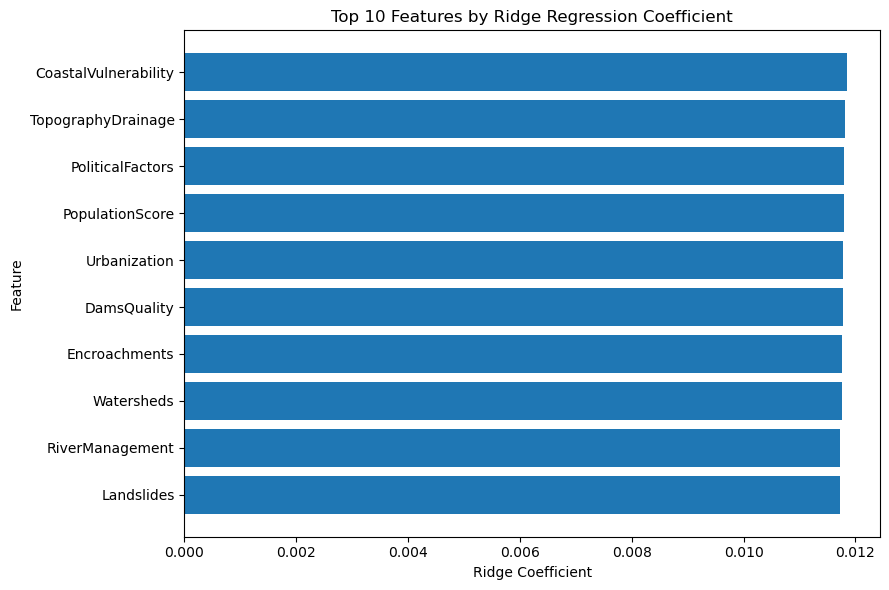

Figure saved to: ../reports/figures\feature_importance.png


In [10]:
plt.figure(figsize=(9, 6))

plt.barh(
    top_10["Feature"][::-1],
    top_10["Coefficient"][::-1]
)

plt.xlabel("Ridge Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features by Ridge Regression Coefficient")

plt.tight_layout()

output_path = os.path.join(FIGURE_DIR, "feature_importance.png")
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Figure saved to: {output_path}")

In [11]:
positive_features = feature_importance[feature_importance["Coefficient"] > 0].head(10)
negative_features = feature_importance[feature_importance["Coefficient"] < 0].sort_values(
    "Coefficient",
    ascending=True
).head(10)

positive_features, negative_features

(                 Feature  Coefficient  Absolute_Coefficient
 12  CoastalVulnerability     0.011847              0.011847
 1     TopographyDrainage     0.011817              0.011817
 19      PoliticalFactors     0.011798              0.011798
 16       PopulationScore     0.011791              0.011791
 4           Urbanization     0.011784              0.011784
 6            DamsQuality     0.011772              0.011772
 9          Encroachments     0.011766              0.011766
 14            Watersheds     0.011765              0.011765
 2        RiverManagement     0.011732              0.011732
 13            Landslides     0.011728              0.011728,
 Empty DataFrame
 Columns: [Feature, Coefficient, Absolute_Coefficient]
 Index: [])

## Feature Importance Summary

Feature importance was analyzed using the coefficients of the Ridge Regression model. Since the Ridge model was trained with standardized features, the coefficient magnitudes can be compared across features.

Features with larger absolute coefficients have stronger influence on the model's predictions. Positive coefficients indicate that higher values of the feature are associated with higher predicted flood probability, while negative coefficients indicate the opposite.

These results should be interpreted as statistical associations within this structured Kaggle dataset, not as direct causal relationships. Future work I want to combine real geospatial data, rainfall, elevation, land cover, river distance(or may be another project?), and historical flood-event records for more realistic flood-risk modeling.